In [1]:
import sys
sys.path.append("../src")
from data import get_datasets
from tensorflow import keras
import matplotlib.pyplot as plt

train_ds, val_ds, test_ds, class_names = get_datasets(img_size=(224, 224))
print(len(class_names), "classes")

Skipping bad file: ..\data\PlantVillage\Tomato__Tomato_YellowLeaf__Curl_Virus\svn-r6Yb5c
15 classes


In [2]:
base = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = keras.layers.RandomFlip("horizontal_and_vertical")(inputs)
x = keras.layers.RandomRotation(0.1)(x)
x = keras.layers.Rescaling(1./127.5, offset=-1)(x)
x = base(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(len(class_names), activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\advai\Documents\plant-disease-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


516/516 ━━━━━━━━━━━━━━━━━━━━ 154s 292ms/step - accuracy: 0.7265 - loss: 0.8640 - val_accuracy: 0.8522 - val_loss: 0.4964
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 154s 299ms/step - accuracy: 0.8465 - loss: 0.4711 - val_accuracy: 0.8745 - val_loss: 0.3997
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 150s 291ms/step - accuracy: 0.8682 - loss: 0.4018 - val_accuracy: 0.8794 - val_loss: 0.3702
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 151s 293ms/step - accuracy: 0.8754 - loss: 0.3739 - val_accuracy: 0.8784 - val_loss: 0.3750
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 152s 294ms/step - accuracy: 0.8826 - loss: 0.3491 - val_accuracy: 0.9046 - val_loss: 0.3188


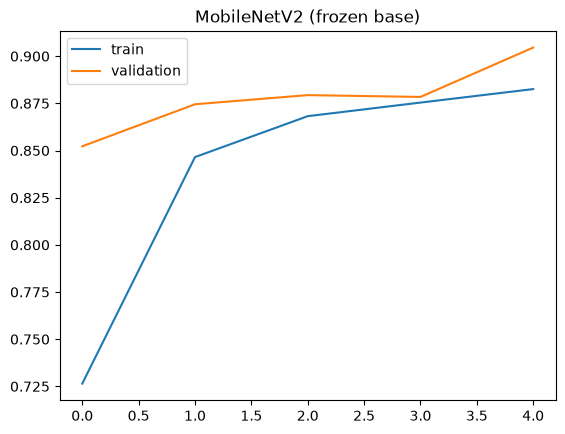

In [4]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.title("MobileNetV2 (frozen base)")
plt.show()

## Transfer learning results
- MobileNetV2 pretrained on ImageNet, base frozen, 5 epochs
- Train accuracy 88%, validation accuracy 90.5% (baseline CNN: 82%)
- Training accuracy is measured with augmentation and dropout switched on, so it can sit below validation accuracy
- Validation accuracy was still rising at epoch 5, so there is room to improve
- Next: unfreeze the top layers of MobileNetV2 and fine-tune